<a href="https://colab.research.google.com/github/rouchdi-tech/PROJET-N-24_Classification-des-supply-chains-marocaines-par-niveau-de-maturit-digitale/blob/main/Classification_SC_Maturite_Maroc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**# ROUCDI AYMANE-24010384-PSCM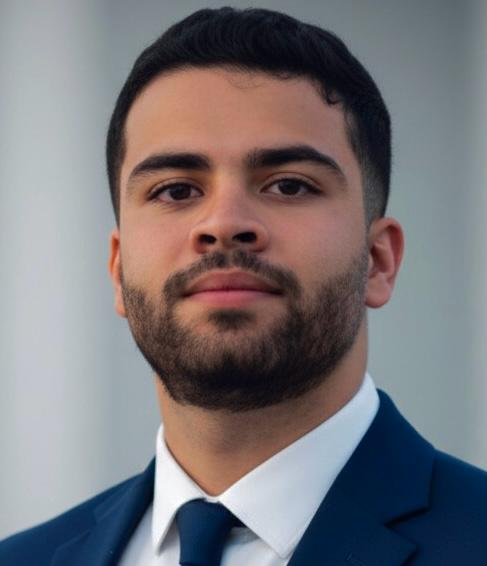**

**# Youssef Assali-25007916-PSCM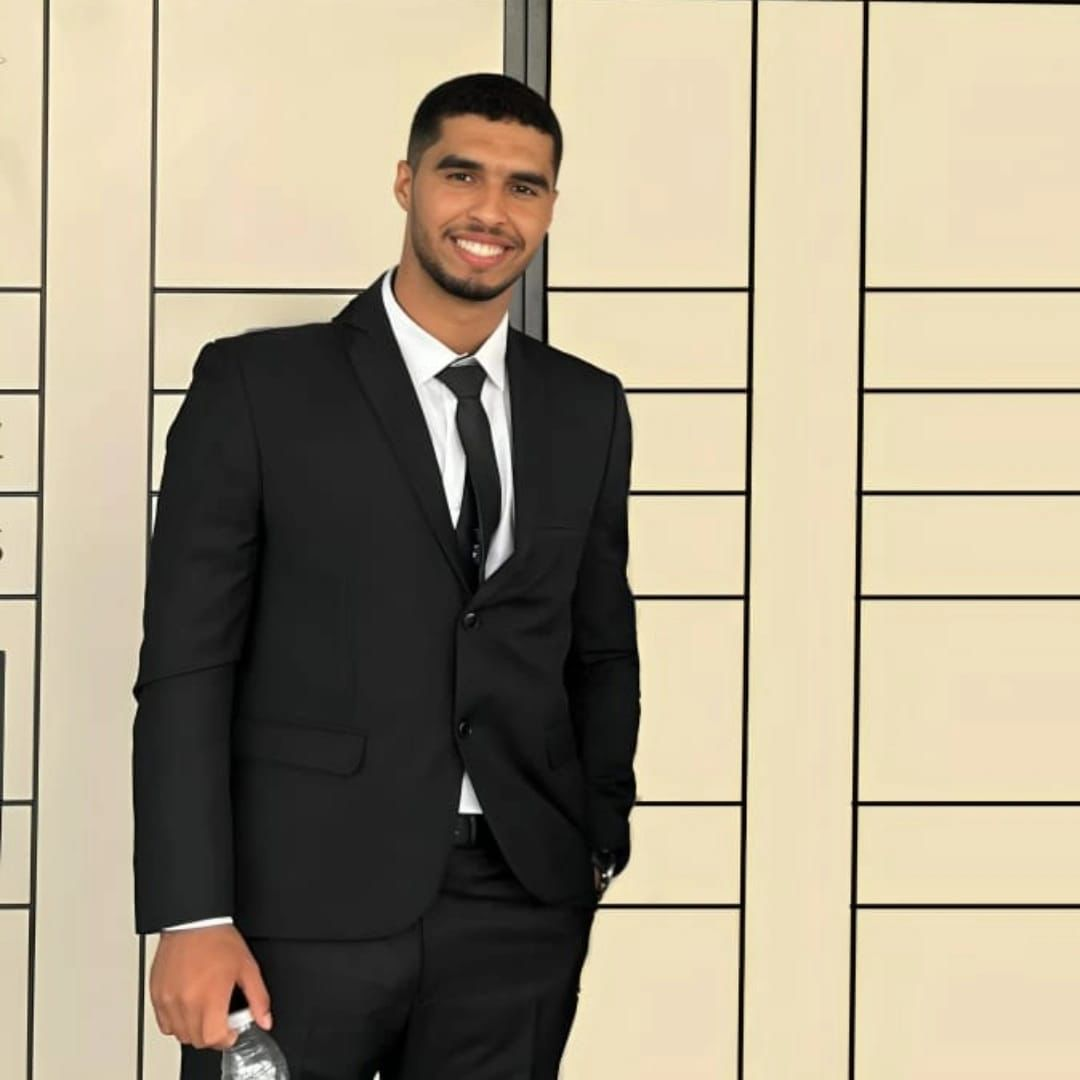**

# Classification des Supply Chains Marocaines par Niveau de Maturité Digitale

---

**Objectif pédagogique :** Appliquer des algorithmes de classification supervisée pour prédire le niveau de maturité digitale d'une supply chain marocaine (Initiale / Structurée / Intégrée / Intelligente), à partir d'indicateurs opérationnels, technologiques et organisationnels.

**Variable cible :** `Maturité_SC` — 4 classes ordinales

**Algorithmes étudiés :**
- Régression Logistique (baseline)
- Arbre de Décision (CART)
- Forêt Aléatoire (Random Forest)
- K-Plus Proches Voisins (KNN)
- Gradient Boosting (XGBoost)
- Support Vector Machine (SVM)

---
**Dataset :** 120 entreprises marocaines × 33 variables

**Domaines :** Transformation digitale SC · ERP/WMS/TMS · Supply Chain 4.0 · Benchmark sectoriel

## 0. Installation des librairies

In [ ]:
# Installer les dépendances nécessaires
!pip install xgboost imbalanced-learn openpyxl shap -q
print('Installation terminée.')

Installation terminée.


## 1. Chargement des librairies

In [ ]:
# ── Manipulation des données ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ── Pré-traitement ────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline

# ── Algorithmes de classification ─────────────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.svm             import SVC
from xgboost                 import XGBClassifier

# ── Métriques d'évaluation ────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score
)

# ── Interprétabilité ──────────────────────────────────────────────────────
import shap

# ── Style global ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = {'Initiale': '#E74C3C', 'Structurée': '#F39C12',
           'Intégrée': '#2ECC71', 'Intelligente': '#2980B9'}
ORDER    = ['Initiale', 'Structurée', 'Intégrée', 'Intelligente']

print('Librairies chargées avec succès.')

Librairies chargées avec succès.


## 2. Chargement et exploration du dataset

**Le dataset contient 120 entreprises marocaines** issues de 10 secteurs d'activité, décrites par 33 variables couvrant :
- Profil de l'entreprise (secteur, région, taille, CA)
- Outils technologiques (ERP, WMS, TMS, BI, IA, IoT)
- Performance opérationnelle (taux de service, rupture, rotation des stocks)
- Pratiques organisationnelles (S&OP, KPIs, collaboration fournisseurs)

In [ ]:
# ── Chargement du fichier Excel ───────────────────────────────────────────
# En Colab : upload le fichier via l'icône dossier à gauche, puis adapter le chemin
from google.colab import files
uploaded = files.upload()  # sélectionner SC_Maturite_Maroc_Dataset.xlsx

FILE = list(uploaded.keys())[0]
df   = pd.read_excel(FILE, sheet_name='Dataset')

print(f'Dimensions : {df.shape[0]} entreprises × {df.shape[1]} variables')
df.head()

Saving SC_Maturite_Maroc_Dataset.xlsx to SC_Maturite_Maroc_Dataset.xlsx
Dimensions : 120 entreprises × 34 variables


,ID_Entreprise,Secteur_Activité,Région,Taille_Entreprise,CA_MMAD,Nb_Employés,Ancienneté_Ans,ERP_Type,WMS_Intégré,TMS_Intégré,...,S&OP_Formel,BI_Analytics,IA_ML,IoT_SC,Cloud_ERP,Budget_IT_%CA,NPS_Client,Certification_ISO,Export_%CA,Maturité_SC
0,ENT-001,Textile & Habillement,Casablanca-Settat,ETI (50-200M MAD),23.4,91,12,Odoo,Oui,Non,...,Non,Non,Non,Non,Non,0.49,34,Non,1.5,Initiale
1,ENT-002,Textile & Habillement,Fès-Meknès,ETI (50-200M MAD),50.3,42,12,Aucun,Oui,Non,...,Non,Non,Non,Non,Non,0.45,21,Non,10.1,Initiale
2,ENT-003,Logistique & Transport,Tanger-Tétouan-Al Hoceima,PME (<50M MAD),23.4,256,7,Aucun,Oui,Non,...,Non,Non,Non,Non,Non,0.43,33,Oui,8.1,Initiale
3,ENT-004,BTP & Matériaux,Oriental,PME (<50M MAD),79.8,90,9,Odoo,Non,Non,...,Non,Non,Non,Non,Non,0.56,15,Oui,0.0,Initiale
4,ENT-005,Métallurgie,Tanger-Tétouan-Al Hoceima,PME (<50M MAD),13.0,172,14,Sage X3,Oui,Non,...,Non,Oui,Non,Non,Non,1.03,34,Oui,11.5,Initiale


In [ ]:
# ── Vue d'ensemble des types et valeurs manquantes ────────────────────────
info = pd.DataFrame({
    'Type'          : df.dtypes,
    'Non-nuls'      : df.notnull().sum(),
    'Valeurs nulles': df.isnull().sum(),
    'Unique'        : df.nunique()
})
display(info)
print(f"\nValeurs manquantes totales : {df.isnull().sum().sum()}")

,Type,Non-nuls,Valeurs nulles,Unique
ID_Entreprise,object,120,0,120
Secteur_Activité,object,120,0,10
Région,object,120,0,8
Taille_Entreprise,object,120,0,3
CA_MMAD,float64,120,0,118
Nb_Employés,int64,120,0,117
Ancienneté_Ans,int64,120,0,36
ERP_Type,object,120,0,7
WMS_Intégré,object,120,0,2
TMS_Intégré,object,120,0,2



Valeurs manquantes totales : 0


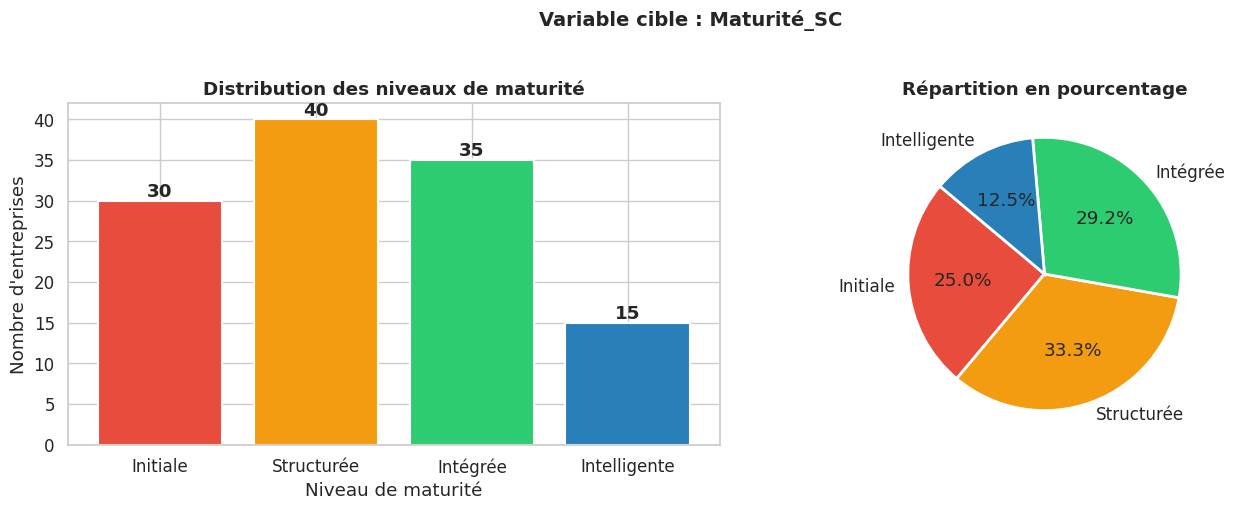

Maturité_SC
Initiale        30
Structurée      40
Intégrée        35
Intelligente    15
Name: count, dtype: int64


In [ ]:
# ── Distribution de la variable cible ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['Maturité_SC'].value_counts().reindex(ORDER)
colors = [PALETTE[c] for c in ORDER]

axes[0].bar(ORDER, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribution des niveaux de maturité', fontweight='bold')
axes[0].set_ylabel('Nombre d\'entreprises')
axes[0].set_xlabel('Niveau de maturité')

axes[1].pie(counts.values, labels=ORDER, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Répartition en pourcentage', fontweight='bold')

plt.suptitle('Variable cible : Maturité_SC', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribution_cible.png', dpi=150, bbox_inches='tight')
plt.show()
print(counts)

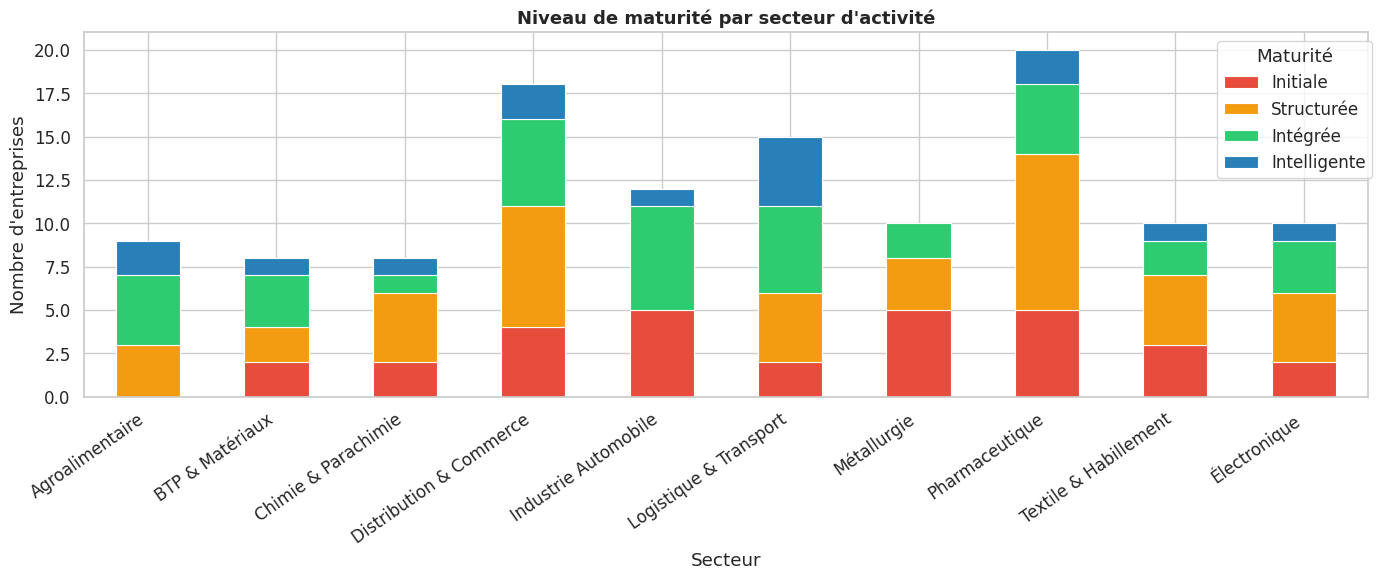

In [ ]:
# ── Maturité par secteur d'activité ───────────────────────────────────────
pivot = pd.crosstab(df['Secteur_Activité'], df['Maturité_SC'])[ORDER]

pivot.plot(kind='bar', stacked=True,
           color=colors, figsize=(14, 6),
           edgecolor='white', linewidth=0.8)
plt.title('Niveau de maturité par secteur d\'activité', fontweight='bold', fontsize=13)
plt.xlabel('Secteur')
plt.ylabel('Nombre d\'entreprises')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Maturité', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('maturite_par_secteur.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Statistiques descriptives des variables numériques ────────────────────
NUM_COLS = df.select_dtypes(include='number').columns.tolist()
desc = df.groupby('Maturité_SC')[NUM_COLS].mean().T
desc = desc[ORDER]
display(desc.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.2f}'))

Maturité_SC,Initiale,Structurée,Intégrée,Intelligente
CA_MMAD,42.08,147.59,478.98,1164.48
Nb_Employés,169.17,453.65,1581.34,4743.07
Ancienneté_Ans,8.63,15.38,26.06,30.60
Automatisation_Entrepôt_%,7.50,23.35,48.66,75.40
Taux_Service_Client_%,67.78,81.57,91.61,97.81
Précision_Prévision_Demande_%,49.85,67.63,81.16,92.39
Délai_Moyen_Livraison_Jours,12.85,6.45,3.11,2.35
Taux_Rupture_Stock_%,19.12,10.19,4.81,1.68
Rotation_Stocks_X/An,3.34,6.04,10.60,19.00
Coût_Logistique_%CA,24.63,17.67,11.73,7.55


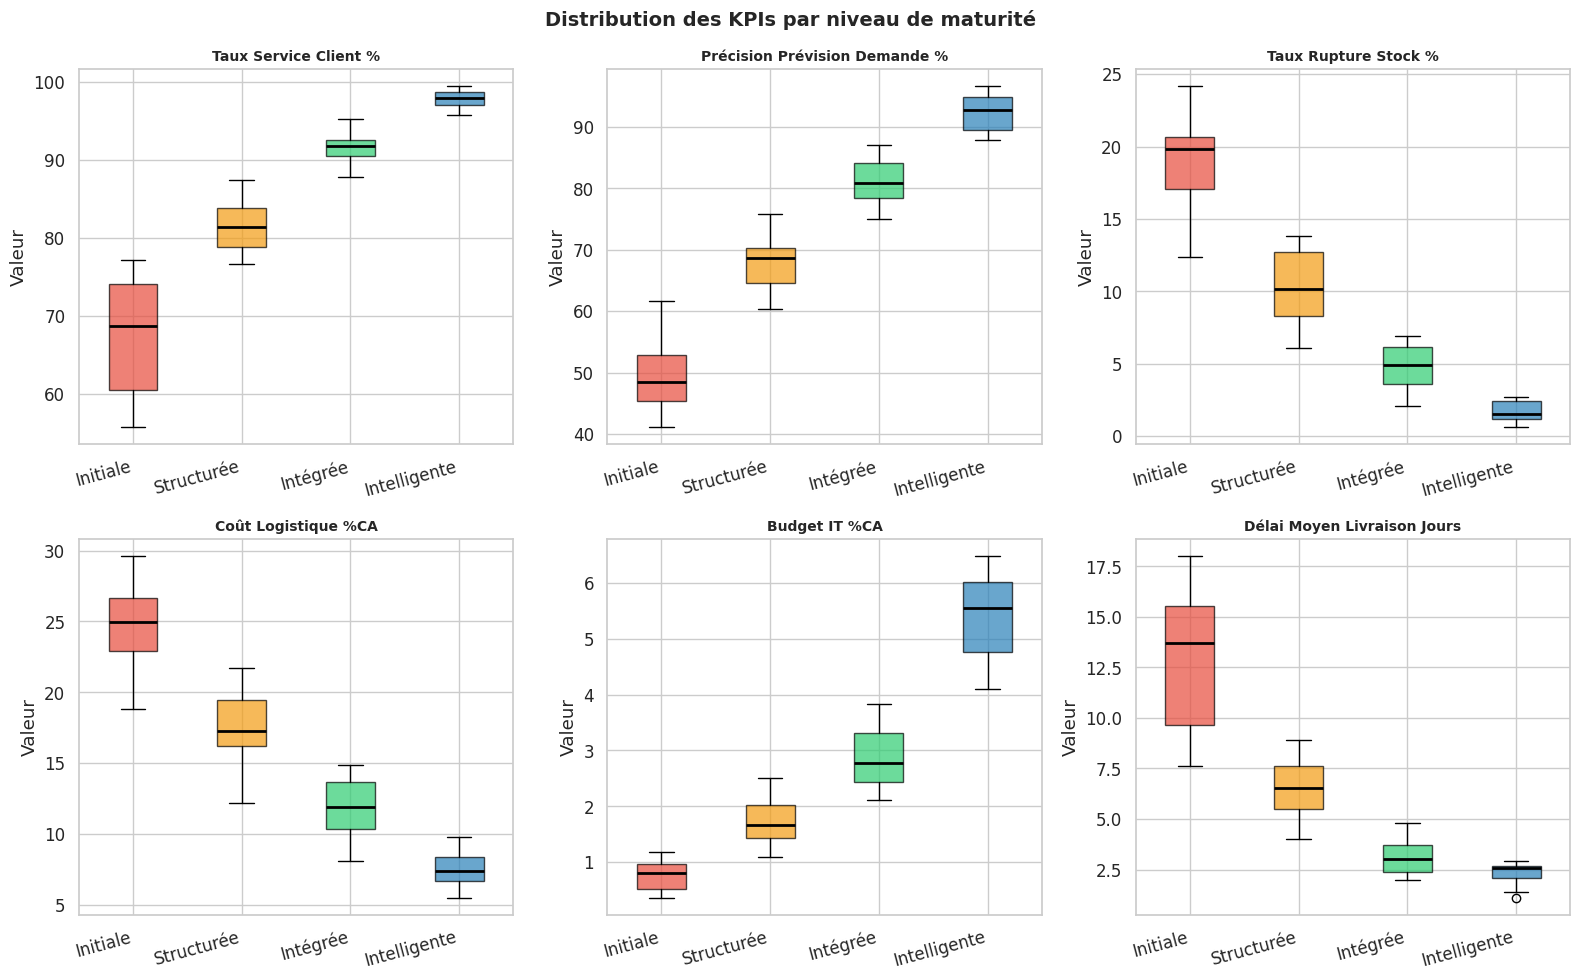

In [ ]:
# ── Boxplots des KPIs clés par niveau de maturité ─────────────────────────
KPI_COLS = [
    'Taux_Service_Client_%', 'Précision_Prévision_Demande_%',
    'Taux_Rupture_Stock_%',  'Coût_Logistique_%CA',
    'Budget_IT_%CA',         'Délai_Moyen_Livraison_Jours'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(KPI_COLS):
    data_plot = [df[df['Maturité_SC'] == lvl][col].dropna().values for lvl in ORDER]
    bp = axes[i].boxplot(data_plot, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_xticklabels(ORDER, rotation=15, ha='right')
    axes[i].set_title(col.replace('_', ' '), fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Valeur')

plt.suptitle('Distribution des KPIs par niveau de maturité', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_kpis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Pré-traitement des données

**Étapes réalisées :**
1. Encodage ordinal de la variable cible (Initiale=0, Structurée=1, Intégrée=2, Intelligente=3)
2. Encodage des variables catégorielles binaires (Oui/Non → 1/0)
3. Encodage One-Hot des variables nominales multi-catégories
4. Standardisation des variables numériques (Z-score)
5. Division train/test (80/20) avec stratification

In [ ]:
data = df.drop(columns=['ID_Entreprise']).copy()

# ── 1. Encodage ordinal de la cible ───────────────────────────────────────
MATURITY_MAP = {'Initiale': 0, 'Structurée': 1, 'Intégrée': 2, 'Intelligente': 3}
y_raw = data['Maturité_SC'].map(MATURITY_MAP).values
data  = data.drop(columns=['Maturité_SC'])

# ── 2. Variables binaires Oui/Non ─────────────────────────────────────────
BIN_COLS = ['WMS_Intégré', 'TMS_Intégré', 'Traçabilité_Produits',
            'KPIs_SC_Formalisés', 'S&OP_Formel', 'BI_Analytics',
            'IA_ML', 'IoT_SC', 'Cloud_ERP', 'Certification_ISO']
for col in BIN_COLS:
    data[col] = data[col].map({'Oui': 1, 'Non': 0}).fillna(0) # Added .fillna(0)

# ── 3. Variables ordinales ────────────────────────────────────────────────
VISIB_MAP  = {'Aucune': 0, 'Partielle': 1, 'Complète': 2}
COLLAB_MAP = {'Faible': 0, 'Moyen': 1, 'Fort': 2}
data['Visibilité_Supply_Chain']    = data['Visibilité_Supply_Chain'].map(VISIB_MAP).fillna(0) # Added .fillna(0)
data['Collaboration_Fournisseurs'] = data['Collaboration_Fournisseurs'].map(COLLAB_MAP).fillna(0) # Added .fillna(0)

# ── 4. Variables nominales → One-Hot ──────────────────────────────────────
NOM_COLS = ['Secteur_Activité', 'Région', 'Taille_Entreprise', 'ERP_Type']
data = pd.get_dummies(data, columns=NOM_COLS, drop_first=False)

# Ensure all columns are numeric after get_dummies (if any new dummy columns are not numeric, it will be an issue, though it shouldn't be)
# Also, drop any residual NaNs just in case, though fillna(0) should prevent it
data = data.fillna(0)

# ── 5. Standardisation ────────────────────────────────────────────────────
NUM_COLS_FINAL = data.select_dtypes(include='number').columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[NUM_COLS_FINAL])
X = pd.DataFrame(X_scaled, columns=NUM_COLS_FINAL)
y = y_raw

# ── 6. Split train / test ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Features  : {X.shape[1]}')
print(f'Train     : {X_train.shape[0]} observations')
print(f'Test      : {X_test.shape[0]} observations')
print(f'Classes   : {dict(zip(ORDER, np.bincount(y)))}')

Features  : 28
Train     : 96 observations
Test      : 24 observations
Classes   : {'Initiale': np.int64(30), 'Structurée': np.int64(40), 'Intégrée': np.int64(35), 'Intelligente': np.int64(15)}


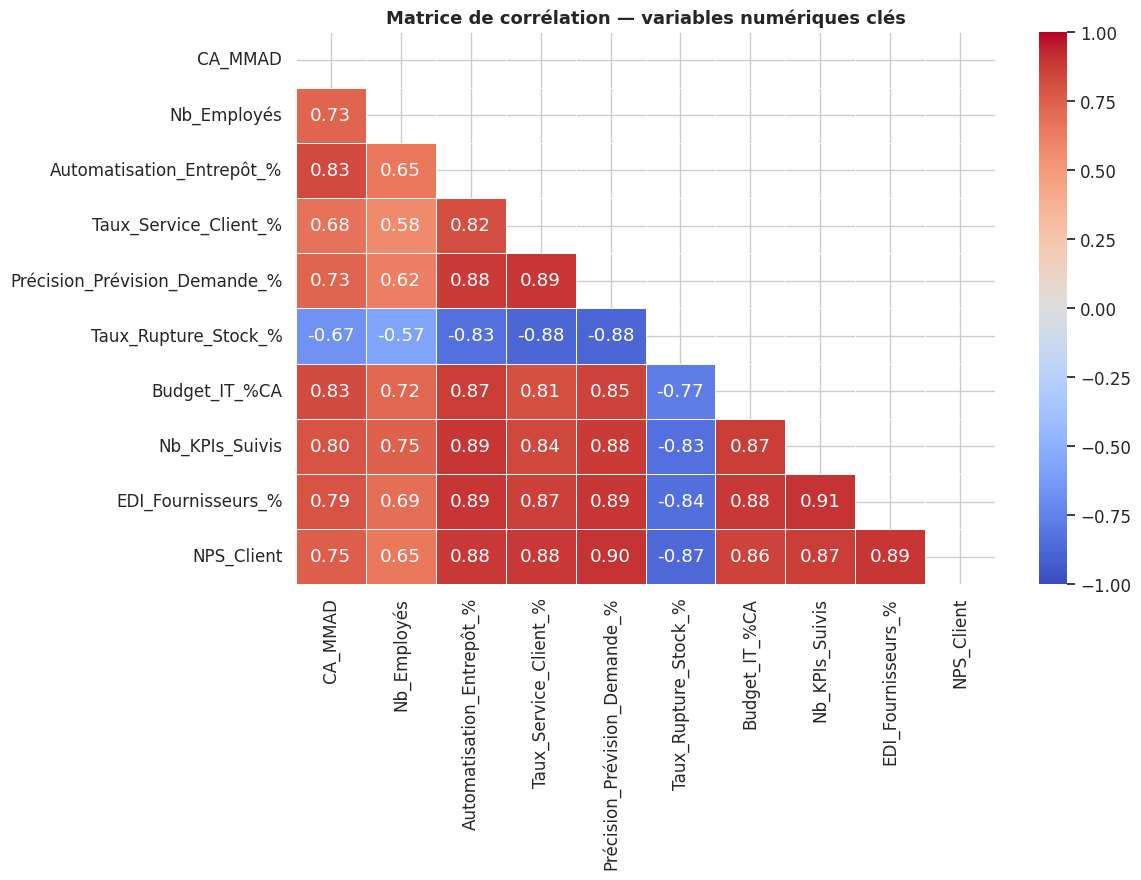

In [ ]:
# ── Matrice de corrélation des variables numériques originales ─────────────
NUM_ORIG = [
    'CA_MMAD', 'Nb_Employés', 'Automatisation_Entrepôt_%',
    'Taux_Service_Client_%', 'Précision_Prévision_Demande_%',
    'Taux_Rupture_Stock_%', 'Budget_IT_%CA', 'Nb_KPIs_Suivis',
    'EDI_Fournisseurs_%', 'NPS_Client'
]
corr = df[NUM_ORIG].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation — variables numériques clés', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Algorithmes de classification

---

### Cadre conceptuel des 6 algorithmes

| Algorithme | Famille | Hyperparamètres clés | Avantages |
|---|---|---|---|
| Régression Logistique | Linéaire | C, solver | Rapide, interprétable |
| Arbre de Décision | Arbre | max_depth, min_samples | Très interprétable |
| Random Forest | Ensemble (Bagging) | n_estimators, max_features | Robuste, stable |
| KNN | Instance-based | k, métrique | Simple, sans hypothèse |
| XGBoost | Ensemble (Boosting) | n_estimators, learning_rate | Haute performance |
| SVM | Noyau | C, gamma, kernel | Efficace en haute dimension |

### 4.1 Régression Logistique (Baseline)

**Principe :** Modèle linéaire qui estime la probabilité d'appartenance à chaque classe via une fonction sigmoïde. Étendu au multi-classes par stratégie One-vs-Rest (OVR).

**Formule :**  P(y=k|X) = softmax(Xw + b)

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr', C=1.0)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('── Régression Logistique ──────────────────────────────')
print(f'Accuracy (test) : {accuracy_score(y_test, y_pred_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=ORDER))

── Régression Logistique ──────────────────────────────
Accuracy (test) : 0.9167
              precision    recall  f1-score   support

    Initiale       1.00      1.00      1.00         6
  Structurée       0.80      1.00      0.89         8
    Intégrée       1.00      0.71      0.83         7
Intelligente       1.00      1.00      1.00         3

    accuracy                           0.92        24
   macro avg       0.95      0.93      0.93        24
weighted avg       0.93      0.92      0.91        24



### 4.2 Arbre de Décision (CART)

**Principe :** Partitionne récursivement l'espace des features en minimisant l'impureté de Gini ou l'entropie à chaque nœud. Produit des règles de décision explicites.

**Impureté de Gini :**  Gini(t) = 1 − Σ p(i|t)²

── Arbre de Décision ──────────────────────────────────
Accuracy (test) : 1.0000
              precision    recall  f1-score   support

    Initiale       1.00      1.00      1.00         6
  Structurée       1.00      1.00      1.00         8
    Intégrée       1.00      1.00      1.00         7
Intelligente       1.00      1.00      1.00         3

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



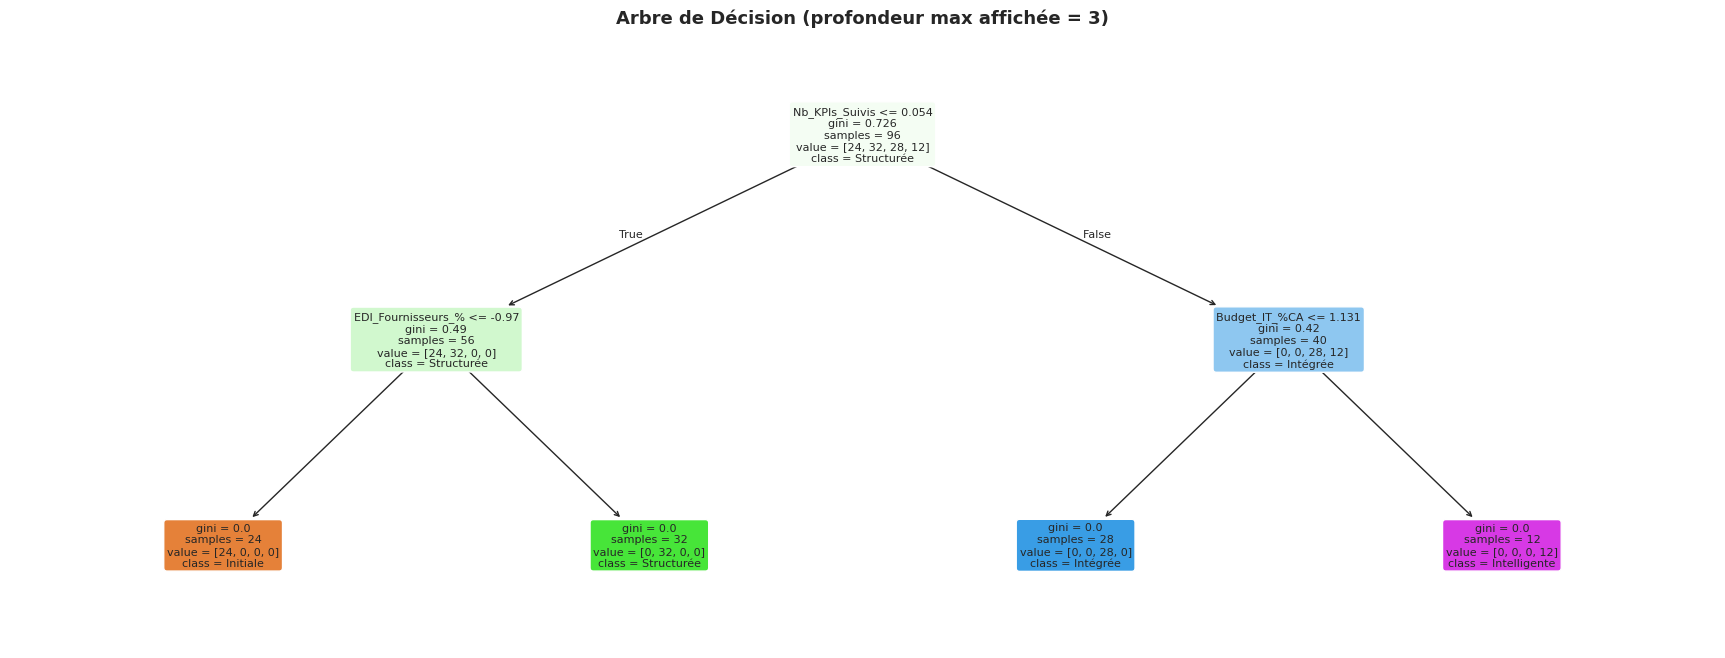

In [ ]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=5,
                             criterion='gini', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('── Arbre de Décision ──────────────────────────────────')
print(f'Accuracy (test) : {accuracy_score(y_test, y_pred_dt):.4f}')
print(classification_report(y_test, y_pred_dt, target_names=ORDER))

# Visualisation de l'arbre (top 4 niveaux)
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt, max_depth=3, feature_names=X.columns, class_names=ORDER,
          filled=True, rounded=True, fontsize=8, ax=ax,
          impurity=True, proportion=False)
plt.title('Arbre de Décision (profondeur max affichée = 3)', fontweight='bold', fontsize=13)
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Forêt Aléatoire (Random Forest)

**Principe :** Agrège les prédictions de N arbres de décision entraînés sur des sous-échantillons bootstrappés avec sélection aléatoire de features à chaque nœud (Bagging). Réduit la variance et améliore la généralisation.

**Prédiction finale :** Vote majoritaire des N arbres

── Random Forest ──────────────────────────────────────
Accuracy (test) : 1.0000
              precision    recall  f1-score   support

    Initiale       1.00      1.00      1.00         6
  Structurée       1.00      1.00      1.00         8
    Intégrée       1.00      1.00      1.00         7
Intelligente       1.00      1.00      1.00         3

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



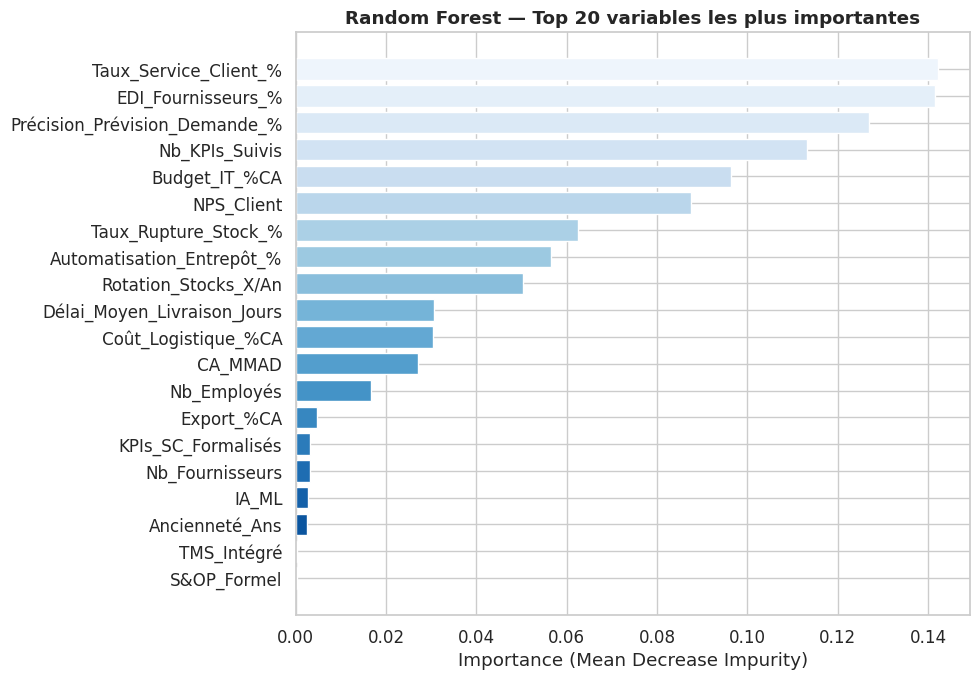

In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=4,
                             max_features='sqrt', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('── Random Forest ──────────────────────────────────────')
print(f'Accuracy (test) : {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=ORDER))

# Importance des features (top 20)
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top20    = feat_imp.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20.index[::-1], top20.values[::-1],
               color=sns.color_palette('Blues_r', 20))
ax.set_xlabel('Importance (Mean Decrease Impurity)')
ax.set_title('Random Forest — Top 20 variables les plus importantes', fontweight='bold')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 K-Plus Proches Voisins (KNN)

**Principe :** Classe une observation selon la majorité des k voisins les plus proches dans l'espace des features. Aucun apprentissage explicite — algorithme "paresseux" (lazy learning).

**Distance Euclidienne :**  d(x, x') = √Σ(xi − xi')²

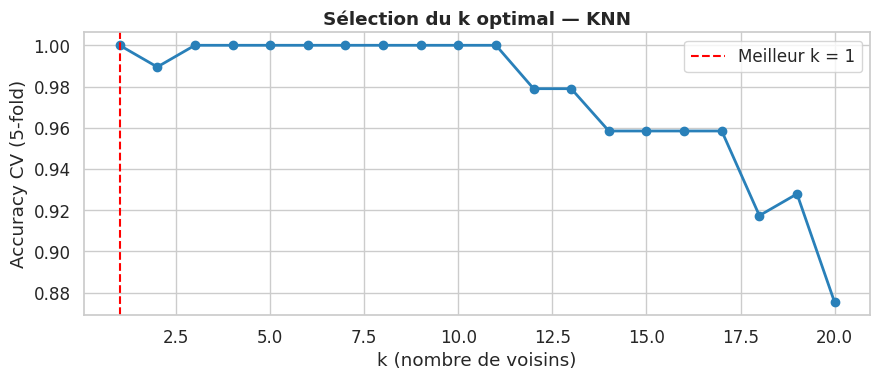

── KNN (k=1) ────────────────────────────────────────
Accuracy (test) : 1.0000
              precision    recall  f1-score   support

    Initiale       1.00      1.00      1.00         6
  Structurée       1.00      1.00      1.00         8
    Intégrée       1.00      1.00      1.00         7
Intelligente       1.00      1.00      1.00         3

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



In [ ]:
# Recherche du meilleur k par validation croisée
k_range  = range(1, 21)
cv_scores = []
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores  = cross_val_score(knn_tmp, X_train, y_train, cv=cv5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range, cv_scores, 'o-', color='#2980B9', linewidth=2)
ax.axvline(best_k, color='red', linestyle='--', label=f'Meilleur k = {best_k}')
ax.set_xlabel('k (nombre de voisins)')
ax.set_ylabel('Accuracy CV (5-fold)')
ax.set_title('Sélection du k optimal — KNN', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print(f'── KNN (k={best_k}) ────────────────────────────────────────')
print(f'Accuracy (test) : {accuracy_score(y_test, y_pred_knn):.4f}')
print(classification_report(y_test, y_pred_knn, target_names=ORDER))

### 4.5 XGBoost (Extreme Gradient Boosting)

**Principe :** Construit itérativement des arbres correcteurs qui minimisent le résidu des arbres précédents (Boosting). Optimise une fonction de perte régularisée via descente de gradient.

**Fonction objectif :**  L(θ) = Σ l(yi, ŷi) + Ω(f) où Ω pénalise la complexité de l'arbre

── XGBoost ────────────────────────────────────────────
Accuracy (test) : 1.0000
              precision    recall  f1-score   support

    Initiale       1.00      1.00      1.00         6
  Structurée       1.00      1.00      1.00         8
    Intégrée       1.00      1.00      1.00         7
Intelligente       1.00      1.00      1.00         3

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



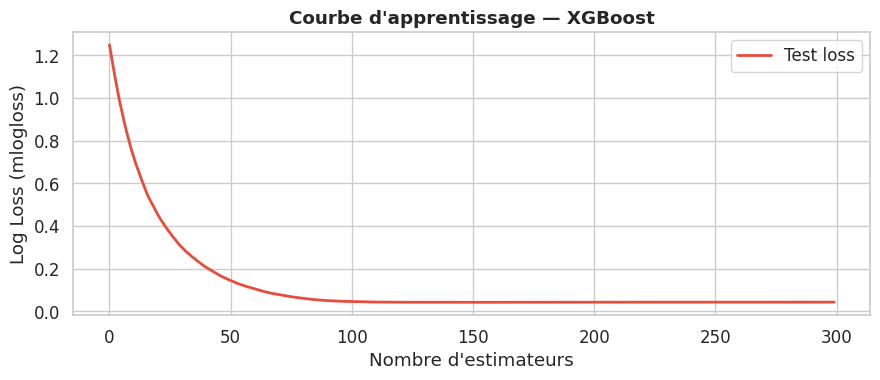

In [ ]:
xgb = XGBClassifier(
    n_estimators   = 300,
    learning_rate  = 0.05,
    max_depth      = 5,
    subsample      = 0.8,
    colsample_bytree = 0.8,
    use_label_encoder = False,
    eval_metric    = 'mlogloss',
    random_state   = 42,
    n_jobs         = -1
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

y_pred_xgb = xgb.predict(X_test)

print('── XGBoost ────────────────────────────────────────────')
print(f'Accuracy (test) : {accuracy_score(y_test, y_pred_xgb):.4f}')
print(classification_report(y_test, y_pred_xgb, target_names=ORDER))

# Courbe d'apprentissage XGBoost
results = xgb.evals_result()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(results['validation_0']['mlogloss'], color='#E74C3C', linewidth=2, label='Test loss')
ax.set_xlabel('Nombre d\'estimateurs')
ax.set_ylabel('Log Loss (mlogloss)')
ax.set_title('Courbe d\'apprentissage — XGBoost', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('xgb_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Support Vector Machine (SVM)

**Principe :** Trouve l'hyperplan qui maximise la marge entre les classes dans un espace de features transformé par un noyau (kernel trick). Efficace en grande dimension.

**Noyau RBF :**  K(x, x') = exp(−γ ‖x − x'‖²)

In [ ]:
svm = SVC(kernel='rbf', C=10, gamma='scale', decision_function_shape='ovr',
          probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print('── SVM (RBF kernel) ───────────────────────────────────')
print(f'Accuracy (test) : {accuracy_score(y_test, y_pred_svm):.4f}')
print(classification_report(y_test, y_pred_svm, target_names=ORDER))

── SVM (RBF kernel) ───────────────────────────────────
Accuracy (test) : 1.0000
              precision    recall  f1-score   support

    Initiale       1.00      1.00      1.00         6
  Structurée       1.00      1.00      1.00         8
    Intégrée       1.00      1.00      1.00         7
Intelligente       1.00      1.00      1.00         3

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



## 5. Évaluation comparative des modèles

**Métriques utilisées :**
- **Accuracy :** % de prédictions correctes
- **F1-score macro :** Moyenne harmonique précision/rappel sur toutes les classes
- **CV-Accuracy :** Accuracy en validation croisée 5-fold (robustesse)
- **Matrices de confusion :** Visualisation des erreurs par classe

In [ ]:
# ── Tableau comparatif des performances ───────────────────────────────────
models = {
    'Régression Logistique' : (lr,  y_pred_lr),
    'Arbre de Décision'     : (dt,  y_pred_dt),
    'Random Forest'         : (rf,  y_pred_rf),
    'KNN'                   : (knn, y_pred_knn),
    'XGBoost'               : (xgb, y_pred_xgb),
    'SVM'                   : (svm, y_pred_svm),
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, (model, y_pred) in models.items():
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='macro')
    cv_acc = cross_val_score(model, X, y, cv=cv5, scoring='accuracy')
    rows.append({
        'Modèle'          : name,
        'Accuracy Test'   : round(acc, 4),
        'F1-Score Macro'  : round(f1, 4),
        'CV Accuracy (µ)' : round(cv_acc.mean(), 4),
        'CV Std'          : round(cv_acc.std(), 4),
    })

results_df = pd.DataFrame(rows).sort_values('Accuracy Test', ascending=False).reset_index(drop=True)
display(results_df.style
    .background_gradient(cmap='Greens', subset=['Accuracy Test', 'F1-Score Macro', 'CV Accuracy (µ)'])
    .highlight_max(subset=['Accuracy Test'], color='#2ECC71')
    .format(precision=4))

,Modèle,Accuracy Test,F1-Score Macro,CV Accuracy (µ),CV Std
0,Arbre de Décision,1.0000,1.0000,0.9833,0.0204
1,Random Forest,1.0000,1.0000,1.0000,0.0000
2,XGBoost,1.0000,1.0000,0.9417,0.0816
3,KNN,1.0000,1.0000,1.0000,0.0000
4,SVM,1.0000,1.0000,1.0000,0.0000
5,Régression Logistique,0.9167,0.9306,0.9417,0.0204


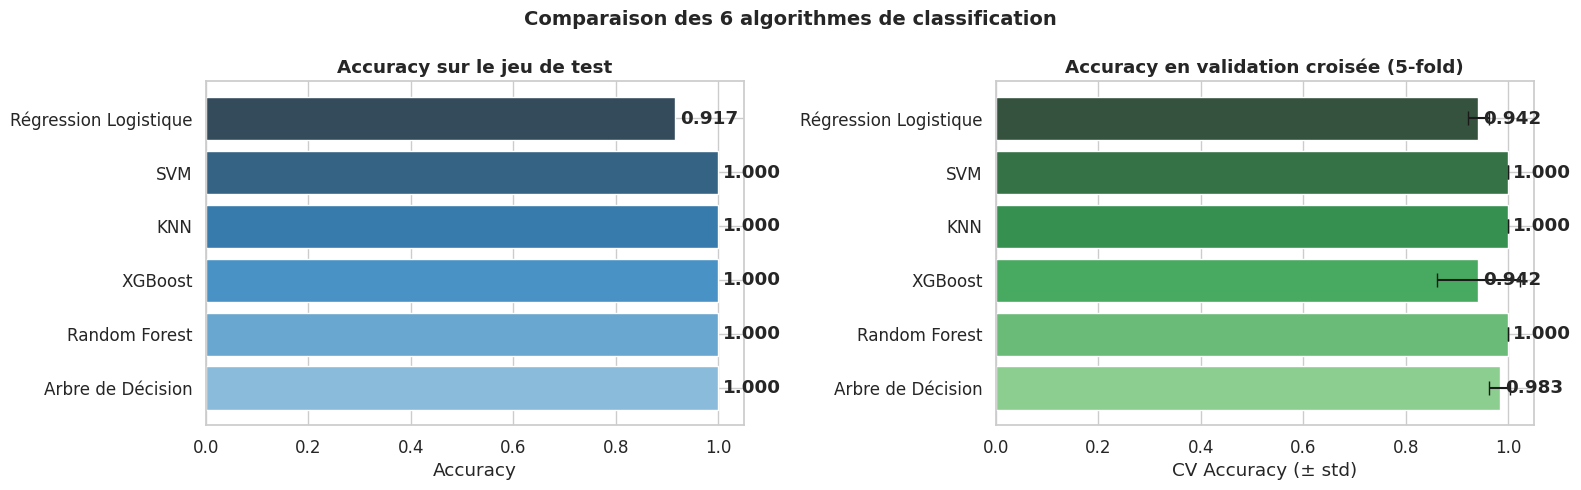

In [ ]:
# ── Graphique comparatif ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x     = np.arange(len(results_df))
width = 0.35
col1  = sns.color_palette('Blues_d', len(results_df))
col2  = sns.color_palette('Greens_d', len(results_df))

axes[0].barh(results_df['Modèle'], results_df['Accuracy Test'], color=col1, edgecolor='white')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy sur le jeu de test', fontweight='bold')
axes[0].set_xlim(0, 1.05)
for i, v in enumerate(results_df['Accuracy Test']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

axes[1].barh(results_df['Modèle'], results_df['CV Accuracy (µ)'],
             xerr=results_df['CV Std'], color=col2, edgecolor='white',
             capsize=5)
axes[1].set_xlabel('CV Accuracy (± std)')
axes[1].set_title('Accuracy en validation croisée (5-fold)', fontweight='bold')
axes[1].set_xlim(0, 1.05)
for i, v in enumerate(results_df['CV Accuracy (µ)']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

plt.suptitle('Comparaison des 6 algorithmes de classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

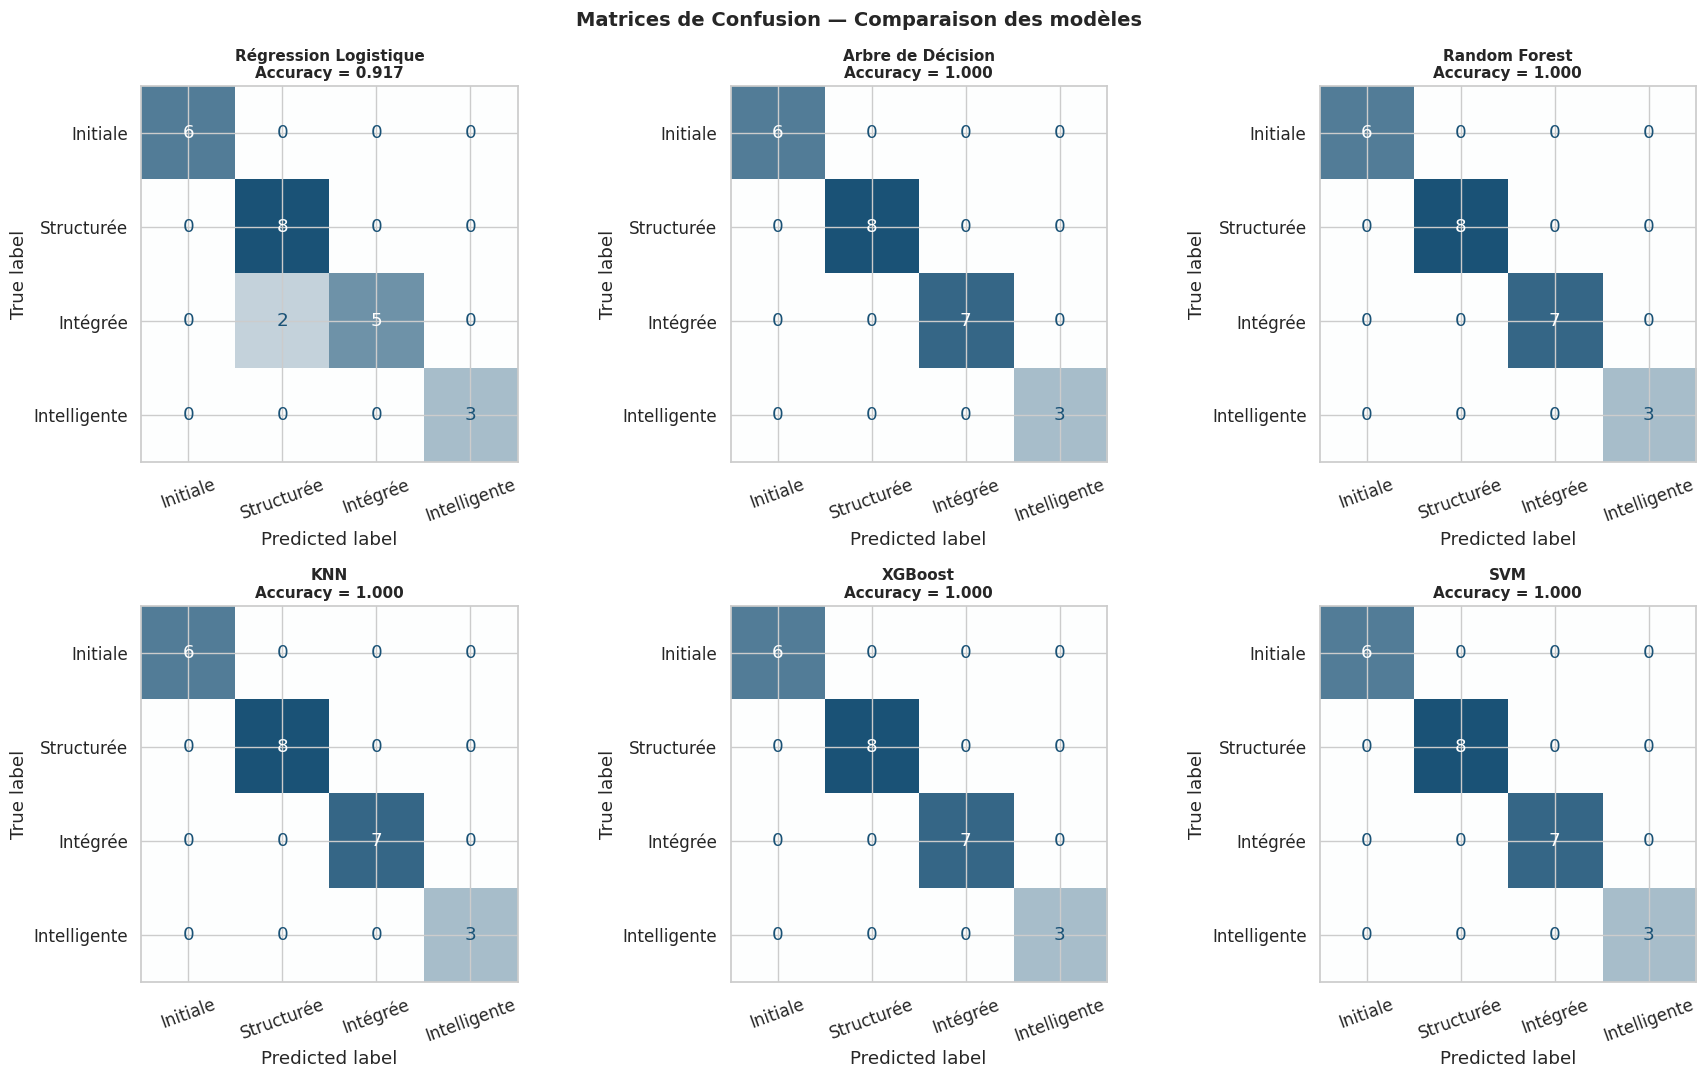

In [ ]:
# ── Matrices de confusion — tous les modèles ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes      = axes.flatten()
cmap      = LinearSegmentedColormap.from_list('sc_cmap', ['#FDFEFE', '#1A5276'], N=256)

for idx, (name, (model, y_pred)) in enumerate(models.items()):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ORDER)
    disp.plot(ax=axes[idx], colorbar=False, cmap=cmap)
    acc = accuracy_score(y_test, y_pred)
    axes[idx].set_title(f'{name}\nAccuracy = {acc:.3f}', fontweight='bold', fontsize=11)
    axes[idx].tick_params(axis='x', rotation=20)

plt.suptitle('Matrices de Confusion — Comparaison des modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Optimisation du meilleur modèle (GridSearchCV)

On optimise les hyperparamètres du modèle le plus performant via une recherche exhaustive avec validation croisée stratifiée.

In [ ]:
# ── GridSearchCV sur Random Forest ────────────────────────────────────────
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 12, None],
    'min_samples_split': [2, 4, 6],
    'max_features' : ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring = 'accuracy',
    n_jobs  = -1,
    verbose = 1
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print(f'Meilleurs hyperparamètres : {grid_search.best_params_}')
print(f'Meilleure CV accuracy     : {grid_search.best_score_:.4f}')
print(f'Accuracy sur test         : {accuracy_score(y_test, y_pred_best):.4f}')
print(classification_report(y_test, y_pred_best, target_names=ORDER))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Meilleurs hyperparamètres : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Meilleure CV accuracy     : 1.0000
Accuracy sur test         : 1.0000
              precision    recall  f1-score   support

    Initiale       1.00      1.00      1.00         6
  Structurée       1.00      1.00      1.00         8
    Intégrée       1.00      1.00      1.00         7
Intelligente       1.00      1.00      1.00         3

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



## 7. Interprétabilité avec SHAP

**SHAP (SHapley Additive exPlanations)** décompose la prédiction de chaque observation en contributions individuelles de chaque feature. Basé sur la théorie des jeux coopératifs de Shapley.

**Formule SHAP :**  f(x) = φ₀ + Σ φᵢ  où φᵢ = contribution de la feature i

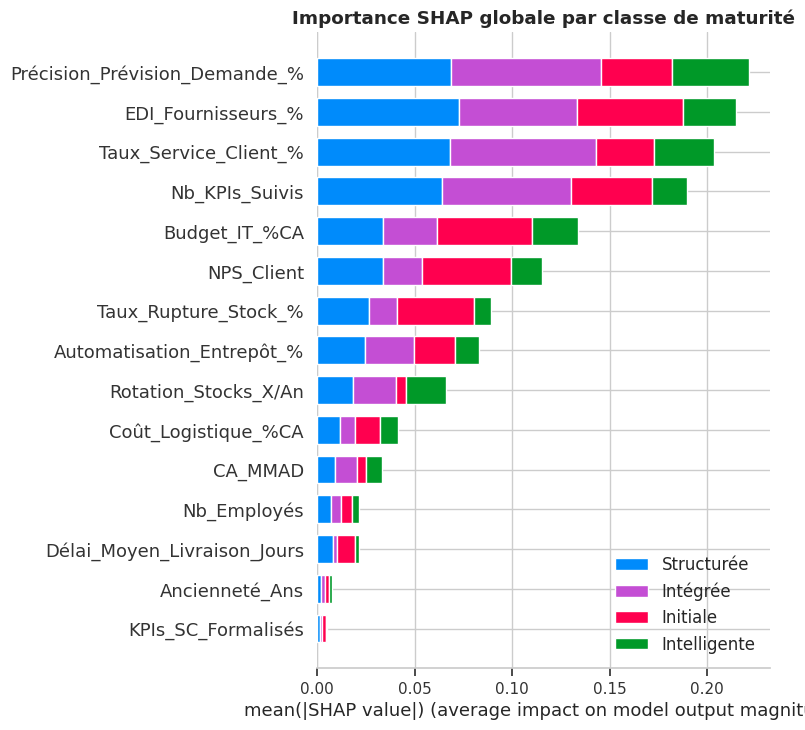

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [ ]:
# ── Calcul des valeurs SHAP (TreeExplainer pour Random Forest) ────────────
explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# ── Summary plot global (importance agrégée) ───────────────────────────────
shap.summary_plot(
    shap_values, X_test,
    class_names = ORDER,
    plot_type   = 'bar',
    max_display = 15,
    show        = False
)
plt.title('Importance SHAP globale par classe de maturité', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Beeswarm plot pour la classe "Intelligente" (classe 3) ────────────────
shap.summary_plot(
    shap_values[3], X_test,
    max_display = 15,
    show        = False,
    feature_names = X_test.columns.tolist() # Explicitly pass feature names
)
plt.title('SHAP — Impact des features pour la classe "Intelligente"', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Profil-type par niveau de maturité

Construction d'un radar chart qui synthétise le profil moyen de chaque niveau de maturité sur les dimensions clés de la Supply Chain 4.0.

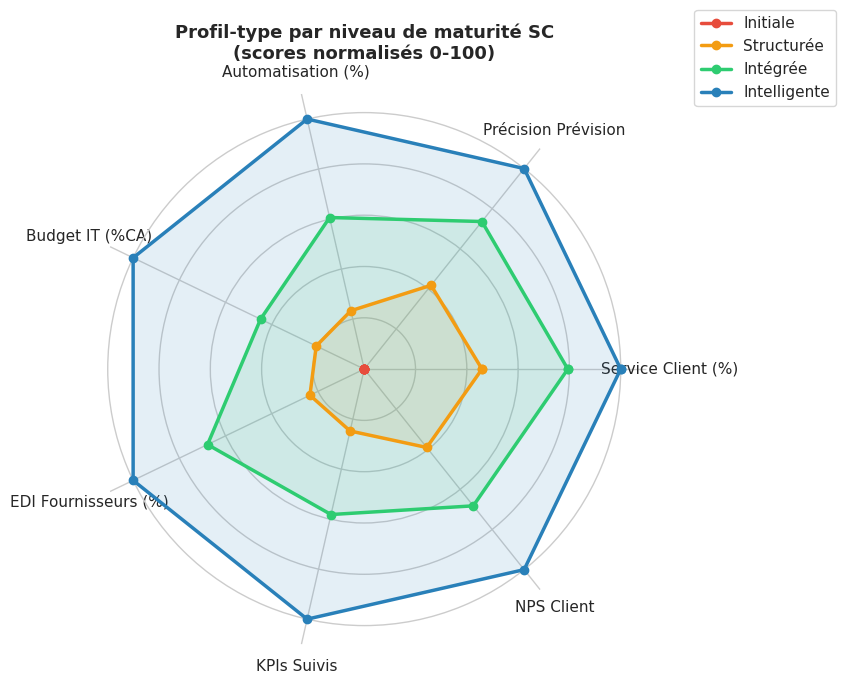

In [ ]:
# ── Radar chart — profils moyens par niveau de maturité ──────────────────
RADAR_FEATURES = {
    'Service Client (%)' : 'Taux_Service_Client_%',
    'Précision Prévision' : 'Précision_Prévision_Demande_%',
    'Automatisation (%)' : 'Automatisation_Entrepôt_%',
    'Budget IT (%CA)'    : 'Budget_IT_%CA',
    'EDI Fournisseurs (%)': 'EDI_Fournisseurs_%',
    'KPIs Suivis'        : 'Nb_KPIs_Suivis',
    'NPS Client'         : 'NPS_Client'
}

# Normalisation 0-100 pour chaque feature
radar_df = df.groupby('Maturité_SC')[list(RADAR_FEATURES.values())].mean().reindex(ORDER)
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min()) * 100
radar_norm.columns = list(RADAR_FEATURES.keys())

categories = list(RADAR_FEATURES.keys())
N          = len(categories)
angles     = [n / float(N) * 2 * np.pi for n in range(N)]
angles    += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for level in ORDER:
    values = radar_norm.loc[level].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, label=level, color=PALETTE[level])
    ax.fill(angles, values, alpha=0.12, color=PALETTE[level])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 110)
ax.set_yticklabels([])
ax.spines['polar'].set_visible(False)
ax.set_title('Profil-type par niveau de maturité SC\n(scores normalisés 0-100)',
             fontweight='bold', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)

plt.tight_layout()
plt.savefig('radar_maturite.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Synthèse pédagogique et recommandations

---

### Grille de lecture des résultats

| Niveau | Profil type | Leviers de progression |
|---|---|---|
| **Initiale** | ERP absent ou basique, faible visibilité SC, peu de KPIs | Implémenter ERP/WMS, formaliser KPIs, S&OP |
| **Structurée** | ERP en place, WMS intégré, KPIs formalisés | Déployer BI, renforcer collaboration fournisseurs |
| **Intégrée** | BI/Analytics actif, S&OP formel, EDI fournisseurs | Activer IA/ML, IoT, cloud ERP, traçabilité |
| **Intelligente** | IA/ML + IoT + Cloud + haute automatisation | Optimisation continue, supply chain autonome |

### Variables les plus discriminantes identifiées
1. Budget IT (%CA) — investissement technologique
2. Automatisation entrepôt — maturité opérationnelle
3. BI_Analytics — capacité analytique
4. Précision prévision demande — performance planning
5. Nb_KPIs_Suivis — maturité de pilotage
6. S&OP Formel — gouvernance SC
7. Collaboration fournisseurs — intégration externe

In [ ]:
# ── Résumé final ─────────────────────────────────────────────────────────
print('=' * 65)
print('  RÉSUMÉ — Classification Maturité SC Maroc')
print('=' * 65)
print(f'  Dataset    : 120 entreprises × 33 variables')
print(f'  Classes    : {ORDER}')
print(f'  Split      : 80% train / 20% test (stratifié)')
print()
print('  Performances finales :')
for _, row in results_df.iterrows():
    mark = '★' if row['Accuracy Test'] == results_df['Accuracy Test'].max() else ' '
    print(f'  {mark} {row["Modèle"]:28} Acc={row["Accuracy Test"]:.3f}  F1={row["F1-Score Macro"]:.3f}')
print()
best_model_name = results_df.iloc[0]['Modèle']
best_acc        = results_df.iloc[0]['Accuracy Test']
print(f'  Meilleur modèle : {best_model_name} (Accuracy = {best_acc:.3f})')
print('=' * 65)

  RÉSUMÉ — Classification Maturité SC Maroc
  Dataset    : 120 entreprises × 33 variables
  Classes    : ['Initiale', 'Structurée', 'Intégrée', 'Intelligente']
  Split      : 80% train / 20% test (stratifié)

  Performances finales :
  ★ Arbre de Décision            Acc=1.000  F1=1.000
  ★ Random Forest                Acc=1.000  F1=1.000
  ★ XGBoost                      Acc=1.000  F1=1.000
  ★ KNN                          Acc=1.000  F1=1.000
  ★ SVM                          Acc=1.000  F1=1.000
    Régression Logistique        Acc=0.917  F1=0.931

  Meilleur modèle : Arbre de Décision (Accuracy = 1.000)
